In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-1.135860,-2.241576,0.730169,-1.401277,1.561721,1
1,-0.644713,0.272833,-1.812691,-0.965589,-2.121808,1
2,-1.721170,-1.901014,-0.628845,-0.690895,-1.965790,1
3,-0.401218,-1.660702,0.884923,-1.551240,2.007868,1
4,1.324033,2.433227,0.396825,-2.307211,2.082765,0


In [8]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [9]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [10]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [22]:
df1 = sample_rows(df,0.2)

In [23]:
df2 = sample_rows(df,0.2)

In [24]:
df3 = sample_rows(df,0.2)

In [25]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')
Index(['col1', 'col2', 'col3', 'col4', 'col5', 'target'], dtype='object')


In [26]:
df3

,col1,col2,col3,col4,col5,target
49,-2.307682,-0.274108,-1.876639,-0.805359,-3.916188,1
94,1.414000,3.541340,0.193362,-3.607806,4.355906,0
94,1.414000,3.541340,0.193362,-3.607806,4.355906,0
39,1.645407,2.100645,0.963968,-3.323823,4.508782,0
69,-1.066825,-0.778917,-1.897837,-0.133053,-1.547715,1
24,1.203770,-1.399857,0.611822,-2.275893,2.509599,1
6,-2.155483,-1.256977,-1.213950,-0.609388,-2.511717,1
86,-0.248234,-1.951339,1.982359,1.978869,-3.544535,0
16,-0.461386,-0.864661,3.133565,-0.511910,-1.260631,0
12,0.122241,-0.688890,1.908380,-0.271029,0.181087,0


In [27]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [33]:
clf1.fit(df1.iloc[:,0:5],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
from sklearn.tree import plot_tree

[Text(0.6, 0.8333333333333334, 'x[0] <= 0.677\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.5, 'x[1] <= 1.051\ngini = 0.165\nsamples = 11\nvalue = [1, 10]'),
 Text(0.5, 0.6666666666666667, 'True  '),
 Text(0.2, 0.16666666666666666, 'gini = 0.0\nsamples = 10\nvalue = [0, 10]'),
 Text(0.6, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [9, 0]'),
 Text(0.7, 0.6666666666666667, '  False')]

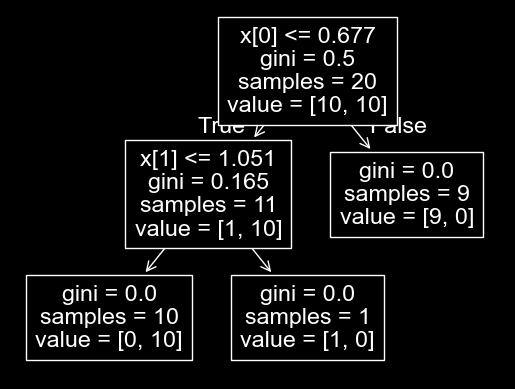

In [35]:
plot_tree(clf1)

[Text(0.3333333333333333, 0.875, 'x[2] <= -0.302\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.16666666666666666, 0.625, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.25, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[0] <= -1.497\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.41666666666666663, 0.75, '  False'),
 Text(0.3333333333333333, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6666666666666666, 0.375, 'x[1] <= -1.337\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.5, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8333333333333334, 0.125, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]')]

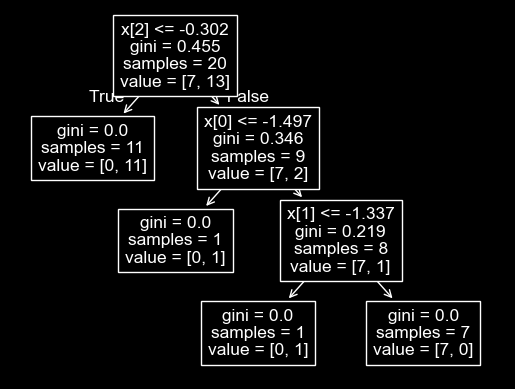

In [36]:
plot_tree(clf2)

[Text(0.5, 0.875, 'x[2] <= 0.172\ngini = 0.455\nsamples = 20\nvalue = [13, 7]'),
 Text(0.2, 0.625, 'x[4] <= -0.744\ngini = 0.375\nsamples = 8\nvalue = [2, 6]'),
 Text(0.35, 0.75, 'True  '),
 Text(0.1, 0.375, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3, 0.375, 'x[4] <= 1.437\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.625, 'x[1] <= -1.212\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.65, 0.75, '  False'),
 Text(0.7, 0.375, 'x[4] <= -0.517\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.6, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.9, 0.375, 'gini = 0.0\nsamples = 10\nvalue = [10, 0]')]

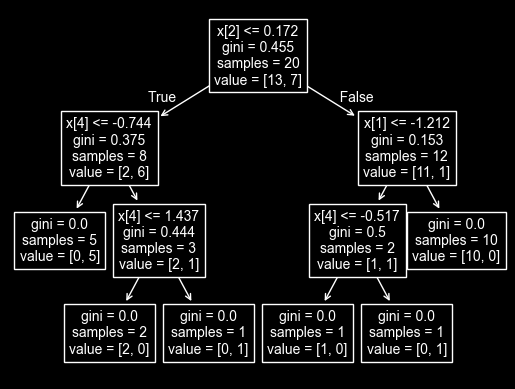

In [37]:
plot_tree(clf3)

In [41]:
clf1.predict(np.array([-1.135860,-2.241576,0.730169	,1.401277,1.561721]).reshape(1,5))

C:\Users\Ronit\pythonbasics\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [42]:
clf2.predict(np.array([-1.135860,-2.241576,0.730169	,1.401277,1.561721]).reshape(1,5))

C:\Users\Ronit\pythonbasics\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [43]:
clf3.predict(np.array([-1.135860,-2.241576,0.730169	,1.401277,1.561721]).reshape(1,5))

C:\Users\Ronit\pythonbasics\tf_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [ ]:
df.sample(14,replace=True)

,humidity,wind,play
0,0,1,0
0,0,1,0
0,0,1,0
10,1,0,1
13,0,0,0
4,1,1,1
7,0,1,0
6,1,0,1
4,1,1,1
3,0,1,1
